In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, SimpleRNN
from sklearn.model_selection import train_test_split

In [3]:
dataframe = pd.read_csv('/content/tesla.csv')  # Ensure the dataset has 'Date' and 'Close' columns
dataframe['Date'] = pd.to_datetime(dataframe['Date'])
dataframe.set_index('Date', inplace=True)

In [4]:
closing_prices = dataframe[['Close']].values
scaler_obj = MinMaxScaler(feature_range=(0, 1))
normalized_data = scaler_obj.fit_transform(closing_prices)

In [5]:
def generate_sequences(data, seq_len):
    X_seq, y_seq = [], []
    for idx in range(len(data) - seq_len):
        X_seq.append(data[idx:idx + seq_len])
        y_seq.append(data[idx + seq_len])
    return np.array(X_seq), np.array(y_seq)

sequence_len = 60  # You can modify the sequence length as needed
X_features, y_labels = generate_sequences(normalized_data, sequence_len)

In [6]:
train_test_split_idx = int(len(X_features) * 0.8)
X_train_data, y_train_data = X_features[:train_test_split_idx], y_labels[:train_test_split_idx]
X_test_data, y_test_data = X_features[train_test_split_idx:], y_labels[train_test_split_idx:]

In [7]:
rnn_model = Sequential()
rnn_model.add(SimpleRNN(units=50, activation='relu', input_shape=(sequence_len, 1)))
rnn_model.add(Dense(1))  # Output layer for predicting the stock price

rnn_model.compile(optimizer='adam', loss='mean_squared_error')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:
training_history = rnn_model.fit(X_train_data, y_train_data, epochs=10, batch_size=32, validation_data=(X_test_data, y_test_data))


Epoch 1/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0524 - val_loss: 0.0016
Epoch 2/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 8.8098e-04 - val_loss: 0.0013
Epoch 3/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 6.4746e-04 - val_loss: 0.0013
Epoch 4/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 7.4372e-04 - val_loss: 0.0012
Epoch 5/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 6.3904e-04 - val_loss: 0.0013
Epoch 6/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5.7949e-04 - val_loss: 0.0011
Epoch 7/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.4439e-04 - val_loss: 0.0011
Epoch 8/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5.8741e-04 - val_loss: 0.0011
Epoch 9/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.8593e-04 - val_loss: 0.0010
Epoch 10/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5.6728e-04 - val_loss: 0.0010


In [9]:
future_predictions = []
recent_sequence = normalized_data[train_test_split_idx - sequence_len:train_test_split_idx]

for _ in range(20):  # Predict for the next 20 days
    recent_sequence = np.reshape(recent_sequence, (1, sequence_len, 1))  # Ensure correct shape for RNN
    predicted_price = rnn_model.predict(recent_sequence)

    future_predictions.append(predicted_price[0][0])  # Store predicted price

    # Reshape predicted price and append it to the sequence
    predicted_price = np.reshape(predicted_price, (1, 1, 1))
    recent_sequence = np.append(recent_sequence[:, 1:, :], predicted_price, axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


In [10]:
predicted_future_prices = scaler_obj.inverse_transform(np.array(future_predictions).reshape(-1, 1))

In [11]:
actual_future_prices = scaler_obj.inverse_transform(normalized_data[train_test_split_idx:train_test_split_idx+20])

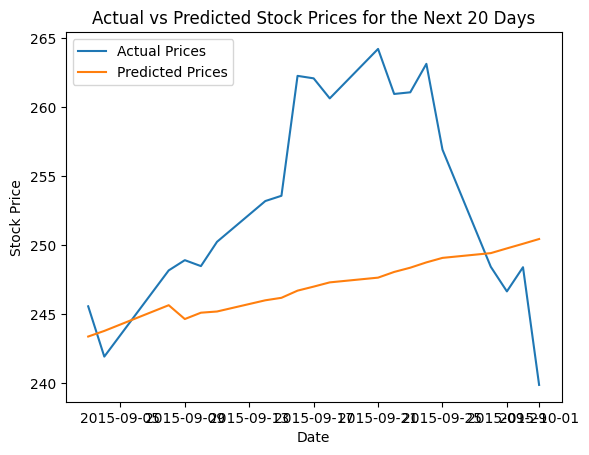

In [12]:
plt.plot(dataframe.index[train_test_split_idx:train_test_split_idx+20], actual_future_prices, label='Actual Prices')
plt.plot(dataframe.index[train_test_split_idx:train_test_split_idx+20], predicted_future_prices, label='Predicted Prices')
plt.title('Actual vs Predicted Stock Prices for the Next 20 Days')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.show()

In [13]:
for day in range(20):
    print(f"Day {day+1}: Actual: {actual_future_prices[day][0]}, Predicted: {predicted_future_prices[day][0]}")

Day 1: Actual: 245.570007, Predicted: 243.38232421875
Day 2: Actual: 241.929993, Predicted: 243.7887725830078
Day 3: Actual: 248.169998, Predicted: 245.6497802734375
Day 4: Actual: 248.910004, Predicted: 244.6491241455078
Day 5: Actual: 248.479996, Predicted: 245.10772705078125
Day 6: Actual: 250.240005, Predicted: 245.1943817138672
Day 7: Actual: 253.190002, Predicted: 246.005615234375
Day 8: Actual: 253.570007, Predicted: 246.1852569580078
Day 9: Actual: 262.25, Predicted: 246.7039031982422
Day 10: Actual: 262.070007, Predicted: 246.9954833984375
Day 11: Actual: 260.619995, Predicted: 247.30239868164062
Day 12: Actual: 264.200012, Predicted: 247.64529418945312
Day 13: Actual: 260.940002, Predicted: 248.05799865722656
Day 14: Actual: 261.059998, Predicted: 248.36508178710938
Day 15: Actual: 263.119995, Predicted: 248.7495574951172
Day 16: Actual: 256.910004, Predicted: 249.0750274658203
Day 17: Actual: 248.429993, Predicted: 249.41952514648438
Day 18: Actual: 246.649994, Predicted: 24